In [33]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [34]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [35]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import temporal_clustering
# reload firefate helpers first, then temporal_clustering so it re-binds fresh names
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(temporal_clustering)
from temporal_clustering import FateFrequency, TFForceWaves, WaveValidation

In [36]:
config = Config()

In [37]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

## Cell state distributions over pseudotime (fate frequency trajectory)

In [38]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [39]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

In [40]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
ff = FateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
pseudotime_values_of_windows = ff.pseudotime_values_of_windows

#### Stacked bar plot of cell states across pseudotime bins

In [41]:
# sanity check: states x windows count table (ActB-1 / earlyActB dropped internally)
display(ff.state_count_per_window.head())

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,193
ActB-2,128,6,0,0,86,78,55,38,34,29,...,0,0,0,0,0,0,0,0,0,0
ActB-3,588,0,0,0,701,753,809,869,892,918,...,0,0,0,0,0,0,0,0,0,0
ActB-4,264,0,0,0,200,157,124,82,66,49,...,0,0,0,0,0,0,0,0,0,0
GC-1,1,0,0,224,0,0,0,0,0,0,...,531,515,468,442,420,375,350,321,294,288
GC-2,10,0,0,776,8,8,8,8,6,3,...,468,484,531,558,580,625,650,679,706,712


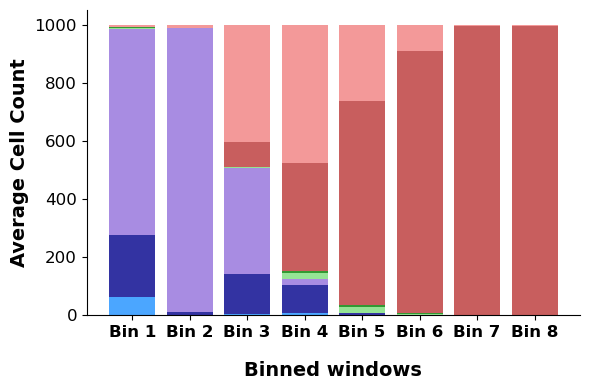

In [42]:
# Stacked bar plot of average cell-state composition over binned windows (PB branch)
fig, ax = ff.plot_stacked_bars(PB_post_bifurcation_window_indices, n_bins=8, figsize=(6, 4))
# fig.savefig(os.path.join(config.OUTPUT_FOLDER, 'fig4_state_count_PB_bins.pdf'), dpi=1200)
plt.show()

### State composition curves

EXTREMA PSEUDOTIMES DICTIONARY

'ActB-2': {
    'maxima': (np.float64(2.788862197039468e-05),),
    'minima': (),
    'all': (np.float64(2.788862197039468e-05),),
}

'ActB-3': {
    'maxima': (np.float64(0.0013253766505282),),
    'minima': (np.float64(0.0006244792104666),),
    'all': (np.float64(0.0006244792104666), np.float64(0.0013253766505282)),
}

'ActB-4': {
    'maxima': (np.float64(0.0006190831524096),),
    'minima': (),
    'all': (np.float64(0.0006190831524096),),
}

'GC-1': {
    'maxima': (np.float64(0.0016619173308904), np.float64(0.0021592495919466)),
    'minima': (),
    'all': (np.float64(0.0016619173308904), np.float64(0.0021592495919466)),
}

'GC-2': {
    'maxima': (),
    'minima': (),
    'all': (),
}

'PB-2': {
    'maxima': (),
    'minima': (),
    'all': (),
}

'earlyPB': {
    'maxima': (np.float64(0.0013253766505282),),
    'minima': (np.float64(0.0005554497650614),),
    'all': (np.float64(0.0005554497650614), np.float64(0.0013253766505282)),
}


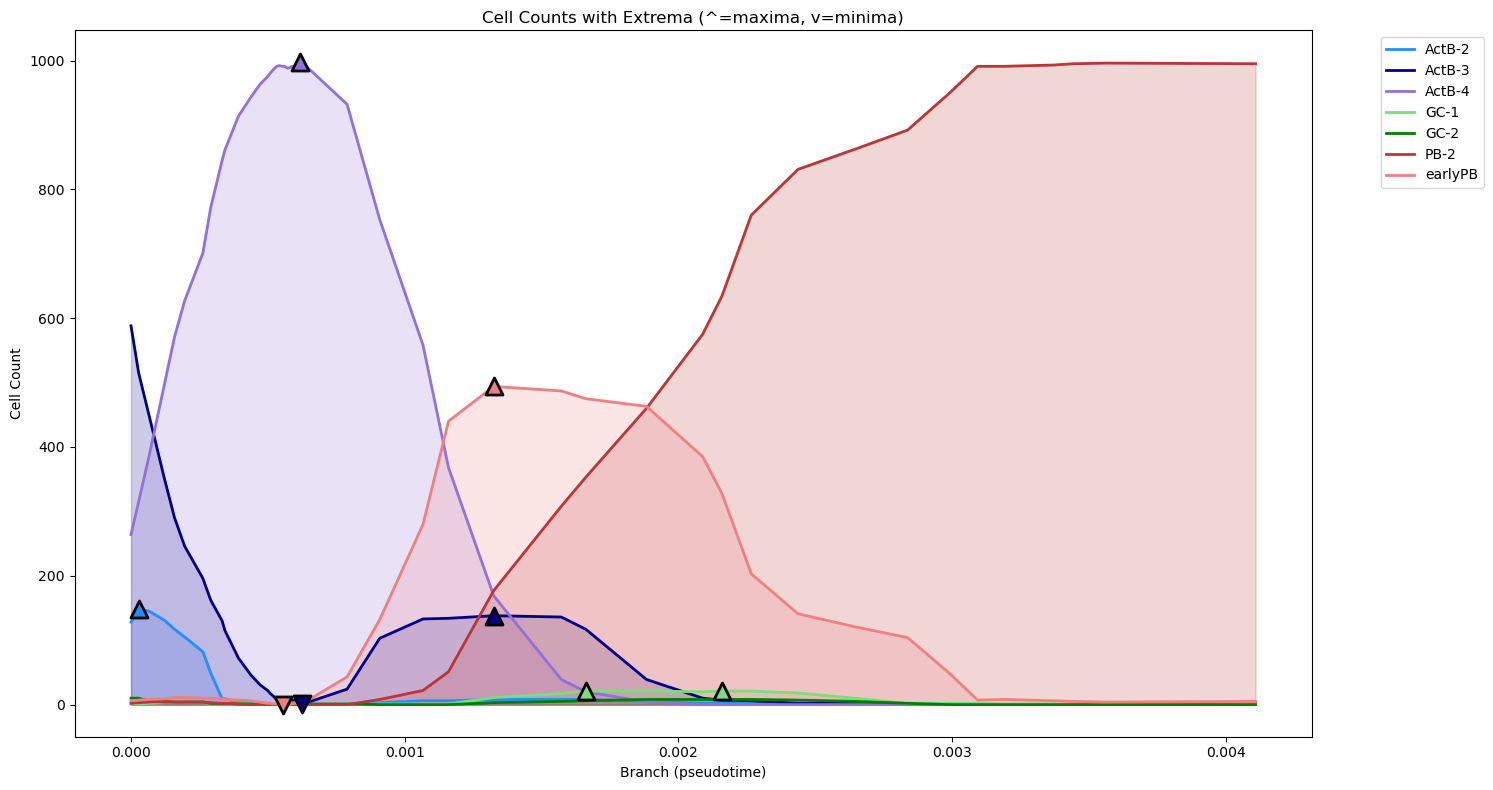

In [43]:
# Per-state extrema (maxima/minima) of the count trajectory
extrema_info, extrema_pseudotimes = ff.find_extrema(
    PB_post_bifurcation_window_indices, prominence=10, distance=3
)

print("=" * 70)
print("EXTREMA PSEUDOTIMES DICTIONARY")
print("=" * 70)
for state, vals in extrema_pseudotimes.items():
    print(f"\n'{state}': {{")
    print(f"    'maxima': {vals['maxima']},")
    print(f"    'minima': {vals['minima']},")
    print(f"    'all': {vals['all']},")
    print("}")

fig, ax = ff.plot_extrema(PB_post_bifurcation_window_indices, prominence=10, distance=3)
plt.show()

# TF Forces

In [44]:
# Class 2: TF forces over pseudotime (expression / regulation curves cached internally)
waves = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

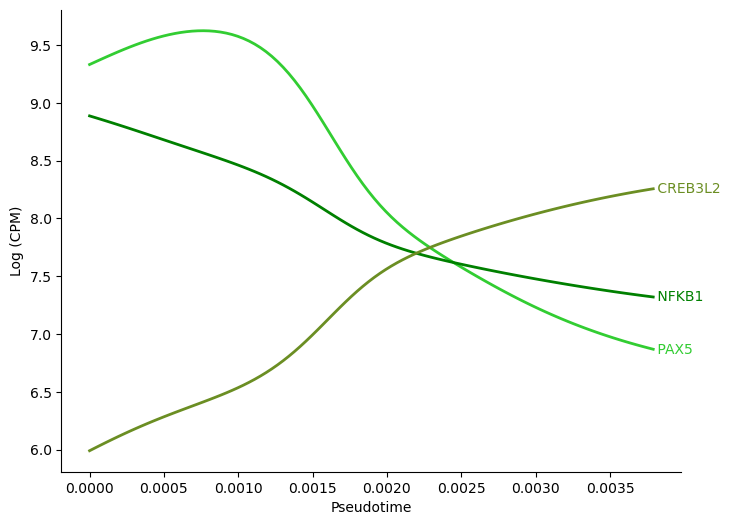

In [45]:
# Plot expression trajectories
# Highlight specific genes
#genes_of_interest_pb = ['CREB3L2','BACH2']
#genes_of_interest_pb = ['XBP1','PRDM1']
genes_of_interest_gc = ['PAX5', 'NFKB1', 'CREB3L2']
#colors_pb = ['blueviolet','slateblue']
colors_gc = ['limegreen', 'green', 'olivedrab']

fig, ax = waves.plot_expression(genes_of_interest_gc, colors_gc, ylabel='Log (CPM)')
# fig.savefig(os.path.join(config.OUTPUT_FOLDER, 'gc_2nd_wave_tfs_expression.pdf'), dpi=300)
plt.show()

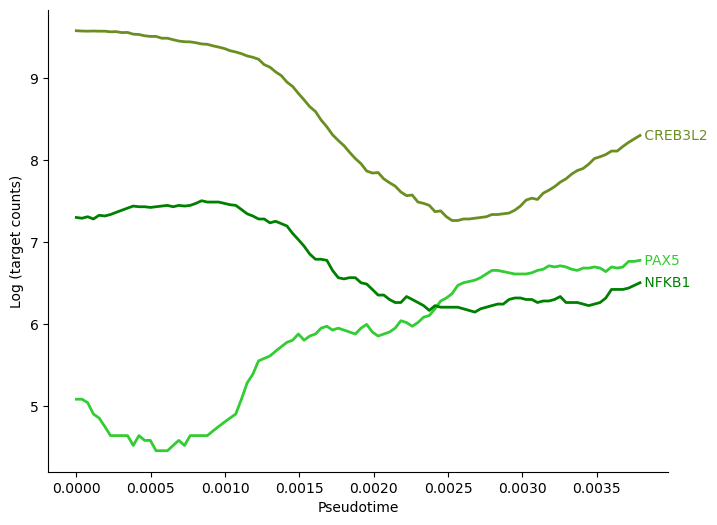

In [46]:
# Plot regulation trajectories
fig, ax = waves.plot_regulation(genes_of_interest_gc, colors_gc, ylabel='Log (target counts)')
# fig.savefig(os.path.join(config.OUTPUT_FOLDER, 'gc_2nd_wave_tfs_regulation.pdf'), dpi=300)
plt.show()

#### Prioritized links

In [47]:
PB_links_plotting = [('BACH2','XBP1'),('IRF4','CDK6'),('CREB3L2','FNDC3A'),('RUNX2','PRDM1'),('CREB3L2','MZB1'),('CREB3L2','RUNX2'),('CREB3L2','TXNDC5'),('TCF12','SEL1L3'),('IRF4','PRDM1'),
                    ('IRF4','ELL2'),('XBP1','HSP90B1'),('XBP1','PPIB'),('XBP1','TXNDC11'),('PRDM1','IRF4'),('CREB3L2','FNDC3B'),('PRDM1','RUNX2')]

In [48]:
GC_links_plotting = [('ARID5B','PIKFYVE'),('ARID5B','PDE4D'),('IRF4','PAX5'),('BATF','PPIB'),('NFKB1','AFF3'),('IRF4','AFF3'),('BACH2','MZB1'),('PAX5','GLCCI1'),
                     ('PAX5','PRDM1'),('CREB3L2','PAX5'),('NFKB1','PAX5')]

In [49]:
# Compute beta / TF-expression / force curves for the prioritized links
force_curves = waves.compute_forces(PB_links_plotting, varname='w_in')
dtime = waves.dtime

In [50]:
display(waves.beta_curves.head())

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                               
IRF4 ELL2   -0.003026 -0.003406 -0.003773 -0.004127 -0.004464 -0.004784   
     IRF4    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
     XBP1   -0.000549 -0.000467 -0.000391 -0.000320 -0.000253 -0.000190   
     MZB1   -0.002576 -0.002623 -0.002682 -0.002753 -0.002835 -0.002928   
     PRDM1   0.002900  0.003254  0.003617  0.003988  0.004366  0.004749   

               time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF   Target                                          ...                       
IRF4 ELL2   -0.005084 -0.005364 -0.005624 -0.005863  ... -0.000438 -0.000605   
     IRF4    0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
     XBP1   -0.000129 -0.000070 -0.000014  0.000039  ...  0.011901  0.011652   
     MZB1   -0.003029 -0.003138 -0.003253 -0.003374  ...  0.014466  0.013973   
     PRDM1   0.005136  0.005525  0.005916  0.006306  ... -0.007108 -0.007590   

              time_92   time_93   time_94   time_95   time_96   time_97  \
TF   Target                                                               
IRF4 ELL2   -0.000758 -0.000897 -0.001025 -0.001141 -0.001247 -0.001344   
     IRF4    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
     XBP1    0.011367  0.011047  0.010694  0.010311  0.009899  0.009460   
     MZB1    0.013458  0.012926  0.012380  0.011823  0.011258  0.010688   
     PRDM1  -0.008014 -0.008382 -0.008695 -0.008955 -0.009166 -0.009330   

              time_98   time_99  
TF   Target                      
IRF4 ELL2   -0.001433 -0.001515  
     IRF4    0.000000  0.000000  
     XBP1    0.008998  0.008513  
     MZB1    0.010115  0.009543  
     PRDM1  -0.009450 -0.009527  

[5 rows x 100 columns]

In [51]:
display(waves.force_curves.head())

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                               
IRF4 ELL2   -0.195281 -0.205603 -0.214997 -0.223547 -0.231317 -0.238362   
     IRF4    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
     XBP1   -0.093039 -0.086730 -0.080310 -0.073639 -0.066519 -0.058658   
     MZB1   -0.182100 -0.183563 -0.185379 -0.187515 -0.189931 -0.192586   
     PRDM1   0.191696  0.201574  0.211089  0.220260  0.229099  0.237614   

               time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF   Target                                          ...                       
IRF4 ELL2   -0.244731 -0.250468 -0.255617 -0.260220  ... -0.092290 -0.106235   
     IRF4    0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
     XBP1   -0.049547 -0.038040 -0.018949  0.029345  ...  0.387352  0.383788   
     MZB1   -0.195433 -0.198429 -0.201530 -0.204700  ...  0.421615  0.415286   
     PRDM1   0.245812  0.253701  0.261290  0.268589  ... -0.309658 -0.318604   

              time_92   time_93   time_94   time_95   time_96   time_97  \
TF   Target                                                               
IRF4 ELL2   -0.117140 -0.126039 -0.133491 -0.139846 -0.145338 -0.150137   
     IRF4    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
     XBP1    0.379656  0.374954  0.369682  0.363838  0.357419  0.350422   
     MZB1    0.408550  0.401429  0.393945  0.386117  0.377962  0.369495   
     PRDM1  -0.326198 -0.332589 -0.337902 -0.342238 -0.345687 -0.348325   

              time_98   time_99  
TF   Target                      
IRF4 ELL2   -0.154370 -0.158138  
     IRF4    0.000000  0.000000  
     XBP1    0.342841  0.334666  
     MZB1    0.360729  0.351674  
     PRDM1  -0.350219 -0.351429  

[5 rows x 100 columns]

#### landscape viz of tf-force across pseudotime

In [52]:
fig2 = waves.plot_landscape('BACH2', 'XBP1')
fig2.show()

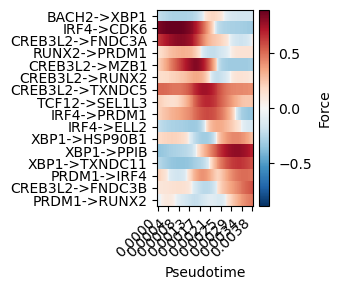

In [53]:
# row_scaling example: {('NFKB1', 'AFF3'): 0.4} scales that link to 40% of its values
force_df_for_cluster, reg_labels, dtime, fig = waves.plot_force_heatmap(
    PB_links_plotting,
    cmap='RdBu_r',
    vmax=None,
    figsize=(3.5, 3),
    row_scaling=None,
)
plt.yticks(fontsize=10)
plt.tight_layout()
# plt.savefig(os.path.join(config.OUTPUT_FOLDER, 'enriched_links_PB_reordered.pdf'), bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [54]:
# Softmax peak pseudotime per link (aggregated)
regulation_pseudotimes = waves.link_peak_pseudotimes(
    PB_links_plotting, top_k=5, temperature=1.0, method='weighted_mean'
)

In [55]:
display(regulation_pseudotimes)

{('BACH2', 'XBP1'): {'pseudotime': 0.0008422765281899079,
  'window_idx': 22,
  'force': -0.28226883774791667,
  'abs_force': 0.28226883774791667,
  'n_points': 5},
 ('CREB3L2', 'FNDC3A'): {'pseudotime': 0.0009188792307838721,
  'window_idx': 24,
  'force': 0.8057581027509233,
  'abs_force': 0.8057581027509233,
  'n_points': 5},
 ('CREB3L2', 'FNDC3B'): {'pseudotime': 0.0037142355436027914,
  'window_idx': 97,
  'force': 0.5560287498089799,
  'abs_force': 0.5560287498089799,
  'n_points': 5},
 ('CREB3L2', 'MZB1'): {'pseudotime': 0.0015313577423095885,
  'window_idx': 40,
  'force': 0.8138417597895018,
  'abs_force': 0.8138417597895018,
  'n_points': 5},
 ('CREB3L2', 'RUNX2'): {'pseudotime': 0.0015696898844502457,
  'window_idx': 41,
  'force': 0.33946050797636923,
  'abs_force': 0.33946050797636923,
  'n_points': 5},
 ('CREB3L2', 'TXNDC5'): {'pseudotime': 0.0018759762908987926,
  'window_idx': 49,
  'force': 0.7484977879306232,
  'abs_force': 0.7484977879306232,
  'n_points': 5},
 ('IRF

## Wave assignment by cell-state termination pseudotimes

In [56]:
# PB -> 3 waves: switch boundaries are the termination pseudotimes of ActB-4 then earlyPB.
# A link lands in wave 1 if its softmax peak <= ActB-4 termination, wave 2 if between the
# two terminations, wave 3 if after earlyPB termination.
for state in ['ActB-4', 'earlyPB']:
    print(state, 'termination pseudotime:',
          ff.termination_pseudotime(state, PB_post_bifurcation_window_indices, method='threshold'))

pb_wave_assignments = waves.classify_waves_from_states(
    ff,
    PB_post_bifurcation_window_indices,
    boundary_states=['ActB-4', 'earlyPB'],
    termination_method='threshold',
    threshold_frac=0.1,
)
display(pb_wave_assignments)

ActB-4 termination pseudotime: 0.0015726266455878
earlyPB termination pseudotime: 0.0029925542947625


,TF,Target,peak_pseudotime,wave
0,IRF4,IRF4,0.000077,1
1,PRDM1,PRDM1,0.000077,1
2,RUNX2,RUNX2,0.000077,1
3,XBP1,XBP1,0.000077,1
4,TCF12,ELL2,0.000536,1
...,...,...,...,...
93,TCF12,PPIB,0.003714,3
94,CREB3L2,FNDC3B,0.003714,3
95,PRDM1,HSP90B1,0.003714,3
96,TCF12,CDK6,0.003714,3


In [57]:
# subset pb_wave_assignments to just the enriched links
mask = pb_wave_assignments[['TF', 'Target']].apply(tuple, axis=1).isin(PB_links_plotting)
enriched_waves = pb_wave_assignments[mask].copy()
enriched_waves['link'] = list(zip(enriched_waves['TF'], enriched_waves['Target']))
enriched_waves = enriched_waves[['link', 'wave']].sort_values('wave').reset_index(drop=True)

display(enriched_waves)

,link,wave
0,"(IRF4, CDK6)",1
1,"(BACH2, XBP1)",1
2,"(CREB3L2, FNDC3A)",1
3,"(RUNX2, PRDM1)",1
4,"(CREB3L2, MZB1)",1
5,"(CREB3L2, RUNX2)",1
6,"(CREB3L2, TXNDC5)",2
7,"(TCF12, SEL1L3)",2
8,"(IRF4, PRDM1)",2
9,"(IRF4, ELL2)",2


# Wave Validation

## Overall trajectory FireFate links vs random links

,link,wave,group,abs_max_force
0,"(BACH2, XBP1)",1,enriched,0.282425
1,"(CREB3L2, FNDC3A)",1,enriched,0.806713
2,"(CREB3L2, MZB1)",1,enriched,0.816719
3,"(CREB3L2, RUNX2)",1,enriched,0.341310
4,"(IRF4, CDK6)",1,enriched,0.889705
5,"(RUNX2, PRDM1)",1,enriched,0.314284
6,"(ZFP90, PDPK1)",1,random,0.176458
7,"(ZNF563, CFAP54)",1,random,0.075331
8,"(ZBTB43, PDPK1)",1,random,0.047396
9,"(ATF1, GPER1)",1,random,0.285808


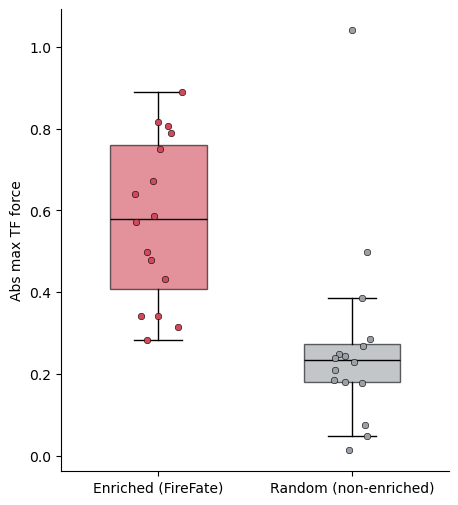

In [58]:
# Validate enriched links vs size-matched random links.
# Random pool is "non-enriched" per `exclude`:
#   'tf_and_target' -> drop every enriched TF and every enriched target (no random
#                      link shares any TF/target with the enriched set; strictest null)
#   'links'         -> keep the full universe, drop only the exact enriched (TF, Target)
#                      pairs (a random link may reuse one of our TFs/targets elsewhere)
# Within each wave a random subset is drawn to match the number of enriched links.
# Switch boundaries are the same termination pseudotimes used for the wave assignment.
switch_pseudotimes = [
    ff.termination_pseudotime(state, PB_post_bifurcation_window_indices, method='threshold')
    for state in ['ActB-4', 'earlyPB']
]

validation = WaveValidation(
    waves,
    enriched_links=PB_links_plotting,
    switch_pseudotimes=switch_pseudotimes,
    varname='w_in',
)
val_df = validation.run(n_tf=40, n_target=40, exclude='tf_and_target', random_state=0)
display(val_df)

# pooled (whole-trajectory) comparison: enriched vs random across all waves
fig, ax = validation.plot_overall(ylabel='Abs max TF force')
plt.show()

## Wave-clustered FireFate links vs random links

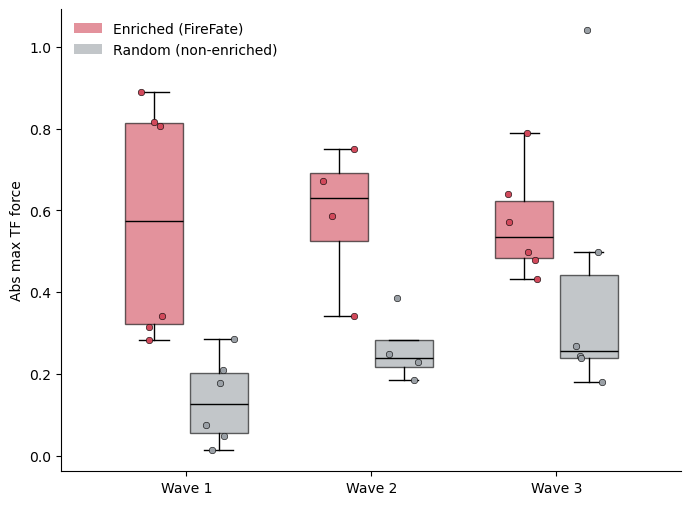

In [59]:
# Per-wave comparison: enriched vs size-matched random links, one group of boxes per wave.
# Each point is one link's abs max TF force (max_t |force(t)|). Reuses the run() above.
fig, ax = validation.plot(ylabel='Abs max TF force')
# fig.savefig(os.path.join(config.OUTPUT_FOLDER, 'wave_validation_PB.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# GC fate -> 2 waves: single switch boundary at the termination pseudotime of ActB-3.
# (compute GC forces first, then classify against the GC post-bifurcation windows)
# gc_force_curves = waves.compute_forces(GC_links_plotting, varname='w_in')
# gc_wave_assignments = waves.classify_waves_from_states(
#     ff,
#     GC_post_bifurcation_window_indices,
#     boundary_states=['ActB-3'],
#     termination_method='threshold',
#     threshold_frac=0.1,
# )
# display(gc_wave_assignments)